In [60]:
'''
what I am looking for  
1. Which category makes the most profit?
(Technology, Furniture, or Office Supplies)
2. Which region makes the least profit?
(East, West, Central, South)
3. Does giving bigger discounts hurt profit?
4. What are the top 5 and bottom 5 products by profit margin?
(margin analysis)
5. What does the monthly sales trend look like across the year?
(Are there seasonal spikes? Q4 holiday effect?)
'''

'\nwhat I am looking for  \n1. Which category makes the most profit?\n(Technology, Furniture, or Office Supplies)\n2. Which region makes the least profit?\n(East, West, Central, South)\n3. Does giving bigger discounts hurt profit?\n4. What are the top 5 and bottom 5 products by profit margin?\n(margin analysis)\n5. What does the monthly sales trend look like across the year?\n(Are there seasonal spikes? Q4 holiday effect?)\n'

In [61]:
# streamlit, we'll use this when deploying the web app
import streamlit as st

# import streamlit as st  
import pandas as pd
import numpy as np

# plotly for visualizations
import plotly.graph_objects as go
import plotly.express as px  # Easier API 
from plotly.subplots import make_subplots

In [62]:
#loading in data and making it usable, mine is from kaggle.com
df = pd.read_csv('data/superstore_data.csv', encoding = 'latin1', low_memory = False)

#convert what you need.
df['Order Date'] = pd.to_datetime(df['Order Date'])
df['Ship Date'] = pd.to_datetime(df['Ship Date'])
df['Sales'] = pd.to_numeric(df['Sales'], errors ='coerce')
df['Profit'] = pd.to_numeric(df['Profit'], errors ='coerce')
df['Discount'] = pd.to_numeric(df['Discount'], errors ='coerce')
df['Quantity'] = pd.to_numeric(df['Quantity'], errors ='coerce')


In [63]:
#optional, I use it as a reference. 
dir(df)
df.columns

Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State',
       'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category',
       'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit'],
      dtype='object')

In [64]:
#make sure all looks good

#check if we have any nulls
print(f'{df.isnull().sum()}')

#check if we have duplicates
print(f'{df.duplicated().sum()}')

#make sure nothing looks crazy
df[['Sales', 'Profit', 'Discount', 'Quantity']].describe()

Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64
0


,Sales,Profit,Discount,Quantity
count,9994.000000,9994.000000,9994.000000,9994.000000
mean,229.858001,28.656896,0.156203,3.789574
std,623.245101,234.260108,0.206452,2.225110
min,0.444000,-6599.978000,0.000000,1.000000
25%,17.280000,1.728750,0.000000,2.000000
50%,54.490000,8.666500,0.200000,3.000000
75%,209.940000,29.364000,0.200000,5.000000
max,22638.480000,8399.976000,0.800000,14.000000


In [65]:
#group by category, sum profit
cat_prof = df.groupby('Category')['Profit'].sum().reset_index()
#sort descending
cat_prof = cat_prof.sort_values('Profit', ascending=False)

print(cat_prof)

          Category       Profit
2       Technology  145454.9481
1  Office Supplies  122490.8008
0        Furniture   18451.2728


In [66]:
#group by region, least profit 
region_data = df.groupby('Region').agg({'Sales':'sum', 'Profit':'sum'}).reset_index()

region_data = region_data.sort_values('Profit', ascending = True)
#get our profit margin from region
region_data['Profit_Margin'] = region_data['Profit'] / region_data['Sales'] * 100
print(region_data)


    Region        Sales       Profit  Profit_Margin
0  Central  501239.8908   39706.3625       7.921629
2    South  391721.9050   46749.4303      11.934342
1     East  678781.2400   91522.7800      13.483399
3     West  725457.8245  108418.4489      14.944831


In [67]:
#Do bigger Discounts hurt profit?
correlation = df['Profit'].corr(df['Discount'])
print(f'correlation: {correlation:.2f}')

#getting rid of outliers, better for chart aesthetic, in my opinion
Discount_df = df[df['Profit'].between(-2000, 2000, inclusive='neither')]

correlation: -0.22


In [91]:
#top 5 and bottom 5 products by profit margin

#defining profit margin in our df
df['Profit_Margin'] = df['Profit']/df['Sales']

#grouping by margin
product_margin = df.groupby('Product Name').agg({
    'Profit': 'sum',
    'Sales': 'sum'
}).reset_index()

#calculate margin percent
product_margin['Margin Percent'] = (product_margin['Profit'] / product_margin['Sales'] * 100).round(2)

top5 = product_margin.sort_values('Margin Percent', ascending = False).head(5)
bottom5 = product_margin.sort_values('Margin Percent', ascending = True).head(5)

print(top5)
print(bottom5)

                                           Product Name   Profit    Sales  \
405   Canon imageCLASS MF7460 Monochrome Digital Las...  1995.99  3991.98   
1567             Tops Green Bar Computer Printout Paper   171.29   342.58   
181                                           Avery 475   133.20   266.40   
1474                   Southworth Structures Collection    36.40    72.80   
1673                                         Xerox 1890   122.35   244.70   

      Margin Percent  
405             50.0  
1567            50.0  
181             50.0  
1474            50.0  
1673            50.0  
                                           Product Name    Profit    Sales  \
605   Eureka Disposable Bags for Sanitaire Vibra Gro...   -4.4660    1.624   
388   Bush Westfield Collection Bookcases, Dark Cher... -190.8522   90.882   
613                    Euro Pro Shark Stick Mini Vacuum -325.6332  170.744   
1215                               Okidata B401 Printer -251.9874  179.991   
1838  Zeb

In [103]:
#monthly sales trend accross the year

#create month comlumn from date
df['Month'] = df['Order Date'].dt.to_period('M')

monthly = df.groupby('Month').agg({
    'Sales': 'sum',
    'Profit':'sum'
}).reset_index()

monthly['Month'] = monthly['Month'].astype(str)
print(monthly)


      Month        Sales      Profit
0   2014-01   14236.8950   2450.1907
1   2014-02    4519.8920    862.3084
2   2014-03   55691.0090    498.7299
3   2014-04   28295.3450   3488.8352
4   2014-05   23648.2870   2738.7096
5   2014-06   34595.1276   4976.5244
6   2014-07   33946.3930   -841.4826
7   2014-08   27909.4685   5318.1050
8   2014-09   81777.3508   8328.0994
9   2014-10   31453.3930   3448.2573
10  2014-11   78628.7167   9292.1269
11  2014-12   69545.6205   8983.5699
12  2015-01   18174.0756  -3281.0070
13  2015-02   11951.4110   2813.8508
14  2015-03   38726.2520   9732.0978
15  2015-04   34195.2085   4187.4962
16  2015-05   30131.6865   4667.8690
17  2015-06   24797.2920   3335.5572
18  2015-07   28765.3250   3288.6483
19  2015-08   36898.3322   5355.8084
20  2015-09   64595.9180   8209.1627
21  2015-10   31404.9235   2817.3660
22  2015-11   75972.5635  12474.7884
23  2015-12   74919.5212   8016.9659
24  2016-01   18542.4910   2824.8233
25  2016-02   22978.8150   5004.5795
2

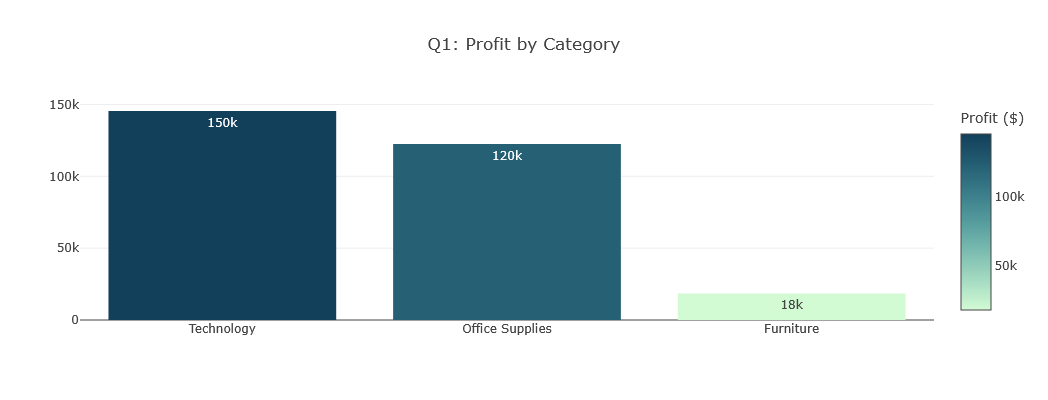

In [69]:
# PLOTLY VISUALIZATION - Q1

# create bar chart using Plotly Express
fig1 = px.bar(
    cat_prof,
    x='Category',
    y='Profit',
    title='Q1: Profit by Category',
    labels={'Category': 'Product Category', 'Profit': 'Profit ($)'},
    color='Profit',  # color by profit value
    color_continuous_scale='darkmint',  # color scheme
    text_auto='.2s'  # show values on bars
)

# Customize layout
fig1.update_layout(
    height = 400,
    xaxis_title = None,
    yaxis_title = None,
    width = 650
)

fig1.show()

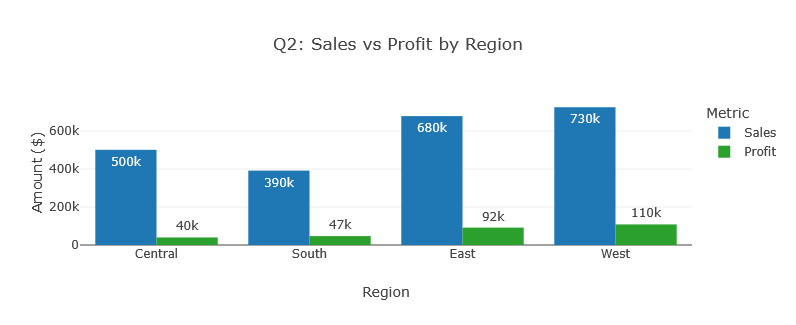

In [15]:
# PLOTLY VISUALIZATION - Q2

# Reshape data for grouped bar chart 
region_melted = region_data.melt(
     id_vars=['Region'],
     value_vars=['Sales', 'Profit'],
     var_name='Metric',
     value_name='Amount'
 )

 # Create grouped bar chart
fig2 = px.bar(
     region_melted,
     x='Region',
     y='Amount',
     color='Metric',  
     barmode='group',  # Side-by-side bars
     title='Q2: Sales vs Profit by Region',
     color_discrete_map={'Sales': '#1f77b4', 'Profit': '#2ca02c'},  # Blue for Sales, Green for Profit
     text_auto='.2s'
 )
fig2.update_layout(height=325,
                  yaxis_title='Amount ($)', 
                  width=650)
fig2.show()

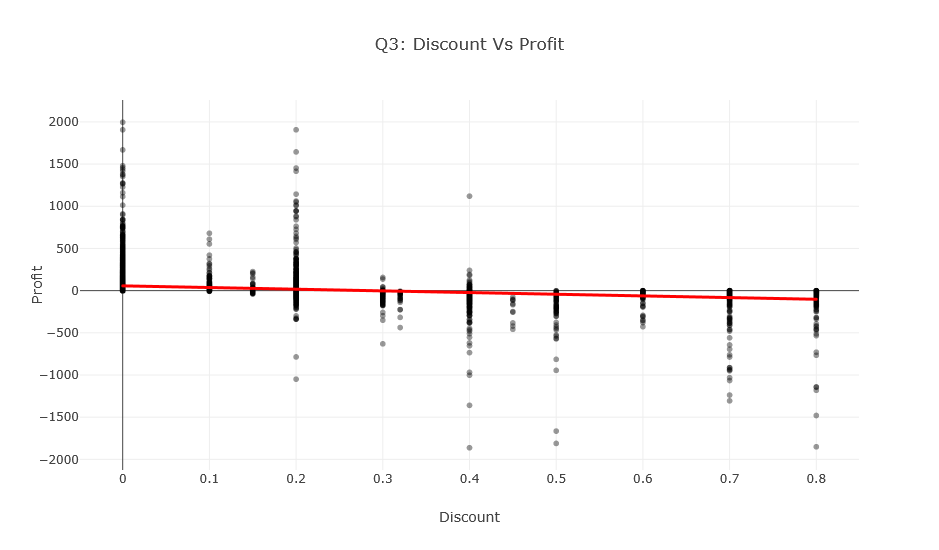

In [53]:
# PLOTLY VISUALIZATION - Q3
fig3 = px.scatter(
    Discount_df,
    x = 'Discount',
    y = 'Profit',
    title = 'Q3: Discount Vs Profit',
    trendline = 'ols',
    opacity = 0.4,
    height = 550,
    width = 600
)

fig3.update_traces(
    line = dict(color = 'red', width = 3)
)

fig3.update_layout(
    xaxis = dict(showgrid = True, gridwidth = 1)
)

fig3.show()

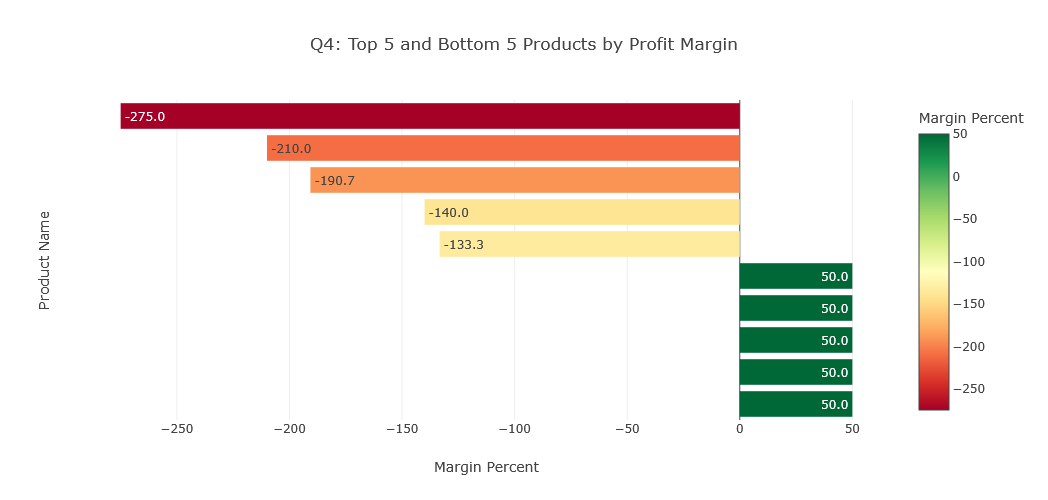

In [101]:
# PLOTLY VISUALIZATION - Q4
#lets combine top5 and bottom5 for our chart
top_bott = pd.concat([top5, bottom5[::-1]])

fig4 = px.bar(
    top_bott,
    y = "Product Name",
    x = 'Margin Percent',
    orientation = 'h',
    title = 'Q4: Top 5 and Bottom 5 Products by Profit Margin',
    color = 'Margin Percent',
    color_continuous_scale = 'RdYlGn',
    text_auto = '.1f'
)

fig4.update_layout(
    height = 500,
    yaxis = {'showticklabels': False}
)
fig4.show()

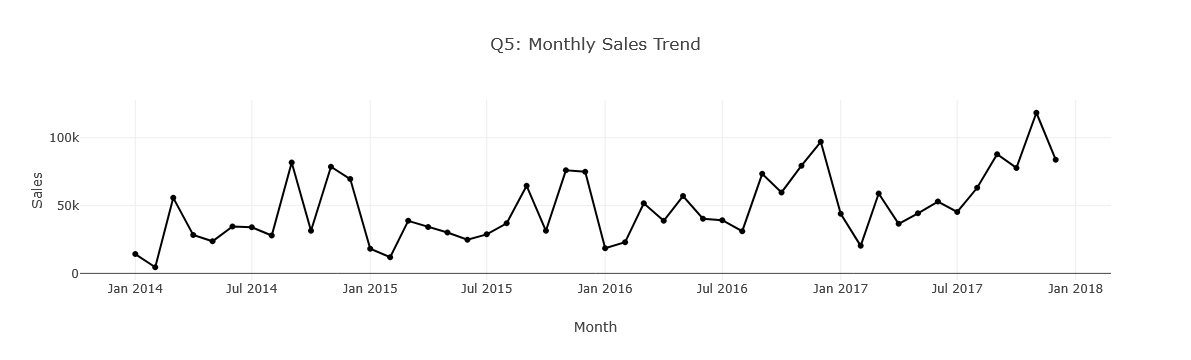

In [105]:
fig5 = px.line(
    monthly,
    x = 'Month',
    y = 'Sales',
    title = 'Q5: Monthly Sales Trend',
    markers =  True
)
fig5.show()